In [57]:
import pandas as pd

df = pd.read_json('/home/bartosz-linux/study/bcmp-networks/logs/HCYGv-Q73b.jsonl', lines=True)


In [58]:
df.head()

,source,ts,action,request_id,old_type,new_type,dest_id
0,WS 1,00:00:213,received,0,NaN,NaN,NaN
1,WS 1,00:00:213,queued,0,NaN,NaN,NaN
2,GN 2,00:00:213,generated,0,NaN,NaN,NaN
3,WS 1,00:00:213,started,0,NaN,NaN,NaN
4,WS 1,00:00:670,received,1,NaN,NaN,NaN


In [59]:
# Convert the timestamp 'ts' column to a standard datetime.timedelta format for easy time calculations
import numpy as np
import datetime as dt

# Convert 'ts' to timedelta
def parse_timestamp(ts):
    try:
        minutes, seconds, milliseconds = map(int, ts.split(':'))
        return dt.timedelta(minutes=minutes, seconds=seconds, milliseconds=milliseconds)
    except:
        return np.nan

df['ts'] = df['ts'].apply(parse_timestamp)

# Filter relevant rows for each calculation by actions
# Extracting queueing and processing stages
queued_df = df[df['action'] == 'queued']
started_df = df[df['action'] == 'started']
processed_df = df[df['action'] == 'processed']

# Calculating average number of requests by class and server
avg_requests_per_class_server = df.groupby(['source', 'new_type'])['request_id'].nunique().groupby(level=0).mean()


# Combining results into a single DataFrame for presentation
results_df = pd.DataFrame({
    'avg_requests_per_class': avg_requests_per_class_server,
}).reset_index()


print(results_df)

  source  avg_requests_per_class
0   WS 1                7.333333
1   WS 2               23.000000
2   WS 3               12.500000
3   WS 4                9.500000
4   WS 5                9.000000


In [64]:
ws1 = df[df['source'] == 'WS 2']
ws1.to_csv('ws1.csv', index=False)

ws1[ws1['request_id'] == 0]

,source,ts,action,request_id,old_type,new_type,dest_id
92,WS 2,0 days 00:00:10.071000,received,0,NaN,NaN,NaN
93,WS 2,0 days 00:00:10.071000,started,0,NaN,NaN,NaN
112,WS 2,0 days 00:00:12.541000,swapped,0,type1,type2,NaN
115,WS 2,0 days 00:00:12.541000,forwarded,0,NaN,NaN,5.0
116,WS 2,0 days 00:00:12.541000,processed,0,NaN,NaN,NaN
138,WS 2,0 days 00:00:15.353000,received,0,NaN,NaN,NaN
139,WS 2,0 days 00:00:15.353000,started,0,NaN,NaN,NaN
155,WS 2,0 days 00:00:16.682000,finished,0,NaN,NaN,NaN
156,WS 2,0 days 00:00:16.682000,processed,0,NaN,NaN,NaN


/tmp/ipykernel_5196/3214365741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ts'] = pd.to_timedelta(data['ts'])


Text(0.5, 1.0, 'Processing Time for each Request')

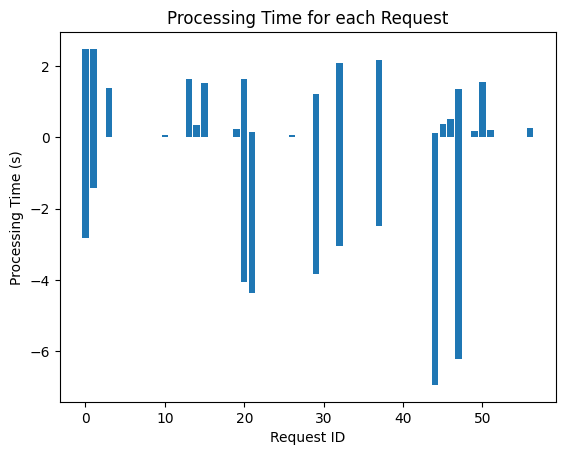

In [67]:
import matplotlib.pyplot as plt
data = ws1
data['ts'] = pd.to_timedelta(data['ts'])
data = data.sort_values(by=['request_id', 'ts'])

# Extract only relevant events for start and end of processing ('received', 'forwarded', 'rejected')
received_df = data[data['action'] == 'received'][['request_id', 'ts']]
end_df = data[data['action'].isin(['forwarded', 'rejected'])][['request_id', 'ts']]
end_df.rename(columns={'ts': 'ts_end'}, inplace=True)


end_df
# # Merge to get the processing time for each request by joining start and end events on request_id
processing_time_df = pd.merge(received_df, end_df, on='request_id', suffixes=('_start', '_end'))
# processing_time_df['processing_time'] = processing_time_df['ts_end'] - processing_time_df['ts_start']
processing_time_df["processint_time"] = processing_time_df["ts_end"] - processing_time_df["ts"]
processing_time_df['processint_time'] = processing_time_df['processint_time'].dt.total_seconds()
processing_time_df


plt.bar(processing_time_df['request_id'], processing_time_df['processint_time'])
plt.xlabel('Request ID')
plt.ylabel('Processing Time (s)')
plt.title('Processing Time for each Request')



In [63]:
processing_time_df

,request_id,ts,ts_end,processint_time
0,0,0 days 00:00:10.071000,0 days 00:00:12.541000,2.470
1,0,0 days 00:00:15.353000,0 days 00:00:12.541000,-2.812
2,1,0 days 00:00:13.891000,0 days 00:00:16.370000,2.479
3,1,0 days 00:00:17.785000,0 days 00:00:16.370000,-1.415
4,3,0 days 00:00:03.238000,0 days 00:00:04.618000,1.380
5,10,0 days 00:00:07.165000,0 days 00:00:07.245000,0.080
6,13,0 days 00:00:09.737000,0 days 00:00:11.378000,1.641
7,14,0 days 00:00:09.174000,0 days 00:00:09.512000,0.338
8,15,0 days 00:00:14.422000,0 days 00:00:15.950000,1.528
9,19,0 days 00:00:16.922000,0 days 00:00:17.144000,0.222


Text(0.5, 1.0, 'Processing Time for each Request')

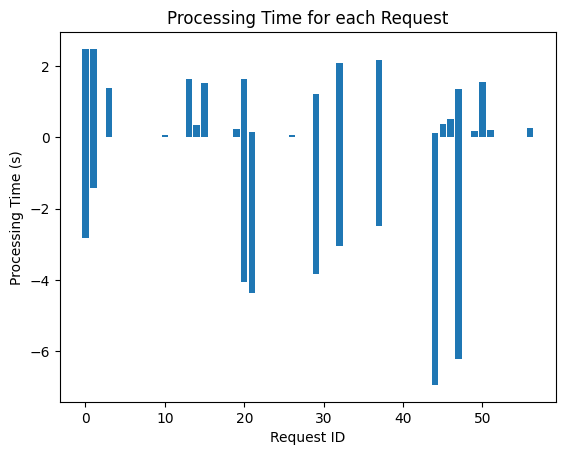

In [62]:
processing_time_df = processing_time_df[processing_time_df['processint_time'] != 0].reset_index(drop=True)

processing_time_df

plt.bar(processing_time_df['request_id'], processing_time_df['processint_time'])
plt.xlabel('Request ID')
plt.ylabel('Processing Time (s)')
plt.title('Processing Time for each Request')
